## Work package 2.1 
1. Methods (notebook) for compiling short-term time-series  (e.g., monthly)  of EO data for WQ monitoring: 


### Steps done:
1. Extract geomedian and wofs data (5 years prior)
2. Extract the data for each sensor
3. Apply QA (sensor-specific)
4. Combine data from the various sensors
3. Apply pre-processing
5. Apply a water mask (estimate the water area)
6. Calculate (and normalise?) FAI values
7. Apply FAI mask
8. Determine OWT and Hue
10. Apply WQ algorithms according to OWT
11. Summarise algorithm results for the month
12. Apply global harmonisation parameters
13. Apply global calibration parameters
14. Take the monthly (median/mean/other) result(s) (per pixel)
15. Compile months for the reference (baseline) period (climatology)
16. Compile months for the monitoring period
17. Compare monitoring period with baseline
18. Raise flags (alerts)
19. Present results ...


### Also To do

### Desirable improvements
- revisit the in-situ comparison and the harmonisation looking at the TC2 Chla algorithm
- develop weights for each chla algorithm based on the OWT, and allow summary values to be calculated as a weighted mean
    - improve OWT estimation by using band 1 in oli and msi
    - return multiple OWTs from the OWT algorithm to support the use of weights when combining

### other ideas

- Possible improvement for monthly data, mask out areas that are 'clear and dry'. See for example fractional cover notebook for methods on wofls. However we are already limiting to areas that are 85% likely to be water, and taking the median for each waterbody. The improvment could be marginal.

- decide how to combine OWT from OLI and MSI


In [461]:
# --- imports --- 
import datacube
import numpy as np
import xarray as xr
import scipy as sp
import gc
import json
from scipy import stats
import pandas as pd     #for dates
from odc.ui import image_aspect
from deafrica_tools.plotting import rgb # used in some visualisation for debugging
dc = datacube.Datacube(app='DoinWhatImdoin') #testing what difference the 'app' value makes...
from deafrica_tools.plotting import display_map

In [751]:
# --- run code for functions that are called
%run /home/jovyan/dev/deafrica_water_quality/WP2.1/_WP21_functions.py              
#%run /home/jovyan/dev/deafrica_water_quality/WP2.2/_WP2.2_functions.py              
%run /home/jovyan/dev/deafrica_water_quality/WP1.2/_WQ_functions.py


In [1726]:
# Set the central latitude and longitude, cell size  




placename = 'testsite'
lon = -12.57; lat = 16.158 ; buffer = 0.15
Xmin,Xmax = lon-buffer, lon+buffer
Ymin,Ymax =  lat-buffer, lat+buffer

placename = 'SA smalldam'
Xmin,Xmax =  19.494, 19.498
Ymin,Ymax = -33.8025, -33.8

placename = 'Vaal_dam' 
lat       = -26.879400; lon = 	28.123050
buffer = 0.1
Xmin,Xmax = lon-buffer, lon+buffer
Ymin,Ymax =  lat-buffer, lat+buffer

placename = 'Loskop_Dam'	
lat = -25.43; lon = 	29.3400	
bufferx = 0.075
buffery = 0.02
Xmin,Xmax = lon-bufferx, lon+bufferx
Ymin,Ymax =  lat-buffery, lat+buffery

placename = 'Lake_Manyana'
Xmin,Xmax =  35.72, 35.92
Ymin,Ymax = -3.35, -3.90

data = ['Abiyata', 38.511, 7.540, 38.6712, 7.6910]
data = ['Langano',  38.674, 7.495, 38.8565, 7.7051]
data = ['few_pixels', 35.82233,  -3.54579,   35.82720, -3.54244]
placename,Xmin,Xmax,Ymin,Ymax = data[0],data[1],data[3],data[2],data[4]
print(f'Processing : {placename}')


Processing : few_pixels


In [1727]:
# filenames
scratch_directory   = '/home/jovyan/deafrica_water_quality/scratch/'
dataset_directory   = '/home/jovyan/deafrica_water_quality/WP21/datasets/'
results_directory   = '/home/jovyan/deafrica_water_quality/WP21/results/'
filename_base       = 'WP21_'
reference_directory = '/home/jovyan/dev/deafrica_water_quality/src/water_quality/data/'
distributions_filename = 'measurement_distributions.csv'
lookup_table_filename  = 'targ_ref_lookup.csv'
np_parameters_filename = 'normalisation_parameters.csv'
dataset_agm_filename = dataset_directory+filename_base+placename+'_agm.nc'
dataset_filename = dataset_directory+filename_base+placename+'.nc'


In [1728]:
# --- controlling parameters and settings
verbose = True 
test    = False
# --- the number of cells in the spatial domain (x,y) used to analyse the waterbody ; Data are resampled guided by this limit 
max_cells = 100000   
max_cells = 10000   

In [1729]:
# over-write temporary data files (e.g., if the location or other parameters are changed)
over_write = True

In [1730]:
# -- other paremeters
notional_cellsize = 100000*(Xmax-Xmin)/max_cells**0.5
cellsizes = np.array([10,20,30,50,100,250,500,1000])
cellsize  = cellsizes[np.argmin(np.abs(cellsizes - notional_cellsize))].item()
resampling_option = 'nearest'
if cellsize < 40 : resample_option = 'bilinear'

validrange = {'tss':(0,1000),'chla':(0,500)}


print('Cell size set to : ',cellsize,'m')
# Preview area on a map
display_map((Xmin,Xmax),(Ymax,Ymin))

Cell size set to :  10 m


In [1984]:
# set date intervals... start_time and end_time ..WIP

reference_date = pd.to_datetime("2005-01-01")
reference_date = pd.to_datetime("2017-01-01")
today          = pd.to_datetime('today')
this_month     = pd.to_datetime(today)
last_month     = this_month - pd.DateOffset(months=1)
months = pd.period_range(
    reference_date,
    last_month,
    freq='M')

m_period = months[np.all(
    (months.month==last_month.month, 
     months.year ==last_month.year),axis=0)]

#start_time = m_period.start_time
#end_time   = m_period.end_time
year1 = months[0].start_time.year
year2 = months[len(months)-1].end_time.year 

In [1989]:
# set xyt and the parameters to build data cubes
xyt = {'x':(Xmin,Xmax),
       'y':(Ymin,Ymax),
       'time':(start_time.strftime('%Y-%m-%d').item(),end_time.strftime('%Y-%m-%d').item())
      }
parameters = {}
parameters['xyt'] = xyt
parameters['place'] = placename
parameters['grid_resolution'] = cellsize
parameters['cell_area'] = cellsize**2
parameters['resampling_option'] = resampling_option
parameters['year1'] = year1
parameters['year2'] = year2
parameters['crs']   = 'EPSG:6933'
# slightly different parameters for the geomedians, start 5 years earlier:
gm_parameters = parameters.copy()
gm_parameters['year1']  = str(year1-5)
# should start the geomedian series from the reference date?
#gm_parameters['year1']  = str((reference_date.year))

In [1961]:
    #read in the harmonisation reference data
    lookup        = pd.read_csv(reference_directory+lookup_table_filename,index_col=0)
    distributions = pd.read_csv(reference_directory+distributions_filename)
    np_data = pd.read_csv(reference_directory+np_parameters_filename)

    # work-around for the chla_tc2 algorithm which is a late arrival and con't be processed on the geomedians
    # this allows the variable to coast through the harmonisation steps without making exceptions later
    lookup.loc[len(lookup)] = ['chla_tc2_msi','chla_tc2_msi']
    np_data.loc[len(np_data)] = ['chla_tc2_msi','chla',0,1,1]

#### 1. Extract dataset of annual geomedians

In [1992]:
# set geomedian instruments, measurements, variable names etc.
gm_instruments_to_use = {
    'oli_agm'  : {'use': True },
    'oli'      : {'use': False},
    'msi_agm'  : {'use': True },
    'msi'      : {'use': False},
    'tm_agm'   : {'use': True },
    'tm'       : {'use': False},
    'tirs'     : {'use': False},  
    'wofs_ann' : {'use': True },
    'wofs_all' : {'use': False},  # wofs_all will be removed as it is better to derive from wofs_ann
    }

gm_instruments_to_use = \
    check_instrument_dates(gm_instruments_to_use,\
                           gm_parameters['year1'],\
                           gm_parameters['year2'],False)

#the line below should not be needed, at least for the agm processing
#gm_instruments,gm_measurements,gm_rename_dict   = instruments_list(gm_instruments_to_use)

In [1993]:
over_write = True

In [1994]:
# build the agm dataset and process its water quality etc.       
verbose = False
keep_all_vars = False
if os.path.exists(dataset_agm_filename) and (over_write == False):
    ds_annual = read_dataset(dataset_agm_filename) 
else:
    print('... building the geomedian dataset for '+placename)
    ds_annual = build_agm_dataset(gm_parameters,gm_instruments_to_use)
    

    ds_annual = detect_geomedian_instruments(ds_annual)
    ds_annual = calculate_agm_count(ds_annual)
    # --- controling parameters for water mapping on a pixel by pixel basis ---
    if True:
        WFTH = water_frequency_threshold_high = 0.5    #this threshold targets areas that are as like as not to be water at any time.
        PWT  = permanent_water_threshold      = 0.875  #used to map annual permanent water (value arrived at through testing)
        SC   = sigma_coefficient              = 1.2    #used to map annual permanent water (value arrived at through tessting)
        ds_annual   = water_analysis(ds_annual,
               water_frequency_threshold= WFTH,
               wofs_varname             = 'wofs_ann_freq',
               permanent_water_threshold= PWT,
               sigma_coefficient        = SC,
               verbose                  = False,
               test                     = test)


    ds_annual              = WOFS_5_year_frequency(ds_annual,False)
    ds_annual['water_5yr'] = xr.where(ds_annual.wofs_5yr_freq>0.45,
                                      ds_annual.wofs_5yr_freq.astype('bool'),np.nan)
    ds_annual = geomedian_FAI(ds_annual,ds_annual.water_5yr)
    ds_annual = geomedian_NDVI(ds_annual,ds_annual.water_5yr)
    ds_annual = set_clearwater(ds_annual,'agm_fai','water_5yr','wofs_ann_water')
    ds_annual = apply_R_correction(ds_annual,
                    ['msi_agm','oli_agm','tm_agm'],
                    water_mask=ds_annual.water_5yr,
                    drop = True, 
                    test = False,verbose=verbose)
    ds_annual = geomedian_hue(ds_annual,ds_annual.clearwater==True,test=False,verbose=verbose)
    ds_annual = run_OWT(ds_annual,agm=True,verbose=verbose)

    gm_instruments = instruments_list(gm_instruments_to_use)[0]
    algorithms_chla,algorithms_tsm = set_wq_algorithms(suffix='_agm')
    dummy,tsm_vlist  = WQ_vars(ds_annual.where(ds_annual.clearwater),
                algorithms_tsm,  
                gm_instruments, 
                new_dimension_name=None, 
                new_varname       =None, 
                verbose=verbose)
    # this two-step process avoids masking other variables
    ds_annual[tsm_vlist] = dummy[tsm_vlist] 
    
    dummy,chla_vlist = WQ_vars(ds_annual.where(ds_annual.clearwater),
                algorithms_chla, 
                gm_instruments, 
                new_dimension_name=None, 
                new_varname       =None,
                verbose=verbose)
    ds_annual[chla_vlist] = dummy[chla_vlist]
    del dummy

    # push  key varibles to their own dimensions
    ds_annual['chla'] = ds_annual[chla_vlist].to_array(dim = 'chla_measure')
    ds_annual['tss']  = ds_annual[tsm_vlist ].to_array(dim = 'tss_measure')
    
    # apply the instrument harmonisation 
    for mmt in 'tss','chla':
        vartype = mmt+'_measure'
        for varname in list(ds_annual[vartype].values):
            ds_annual[mmt].loc[{vartype :[varname]}]= \
                harmonise_for_instrument(
                    ds_annual[mmt].loc[{vartype :[varname]}],
                    varname,
                    lookup,
                    distributions,
                    test=False)

    # Variable to variable harmonisation
    # --- add the scale and offset parameters into the dataset for simplicity in the follwoing steps
    for var in ['chla','tss']:
        measures = ds_annual[var+'_measure']
        for thing in ['scale','offset','era_factor']:
            ds_annual[var+'_'+thing] = (var+'_measure'),np_data.set_index('measurement').loc[measures,thing]

    #apply linear transformations to the variables
    for var in ['tss','chla']:
        ds_annual[var] = \
        (((ds_annual[var] \
         * ds_annual[var+'_scale']) \
         + ds_annual[var+'_offset']) \
         * ds_annual[var+'_era_factor']).\
            clip(validrange[var][0],validrange[var][1])
    
    ds_annual['red'] = ds_annual.msi04_agm
    ds_annual['green'] = ds_annual.msi03_agm
    ds_annual['blue'] = ds_annual.msi02_agm
    keeplist = ['tss','chla',
                'tm_agm','oli_agm','msi_agm',
                'tm_agm_fai','oli_agm_fai','msi_agm_fai','agm_fai','agm_ndvi',
                'clearwater','water_5yr','wofs_ann_water',
                'msi_agm_owt','oli_agm_owt',
                'agm_hue',
                'agm_hue','red','green','blue'
               ]
    if not keep_all_vars:
        droplist = set(ds_annual.data_vars)  - set(keeplist)
        ds_annual  = ds_annual.drop_vars(droplist)

    
    # reduce the tss and chla variables
    for var in 'tss','chla':
        ds_annual[var] = ds_annual[var]\
            .clip(validrange[var][0],validrange[var][1])\
            .median(dim=var+'_measure')
    ds_annual = ds_annual.drop_dims(['tss_measure','chla_measure'])

    ds_annual.to_netcdf(dataset_agm_filename) 
    
# apply global calibration 
ds_annual['chla'] = calibrate(ds_annual.chla,'chla')
ds_annual['tss']  = calibrate(ds_annual.tss,'tss')

... building the geomedian dataset for few_pixels

Building the Geomedian dataset:
loading data for  oli_agm ...
loading data for  msi_agm ...
loading data for  tm_agm ...
loading data for  wofs_ann ...
---variable -->   msi01_agm   <-- anticipated but not found in the dataset (non-fatal)
---variable -->   oli01_agm   <-- anticipated but not found in the dataset (non-fatal)

 Aborting hue calculation for instrument  oli  due to lack of necessary data bands



##### .... check results

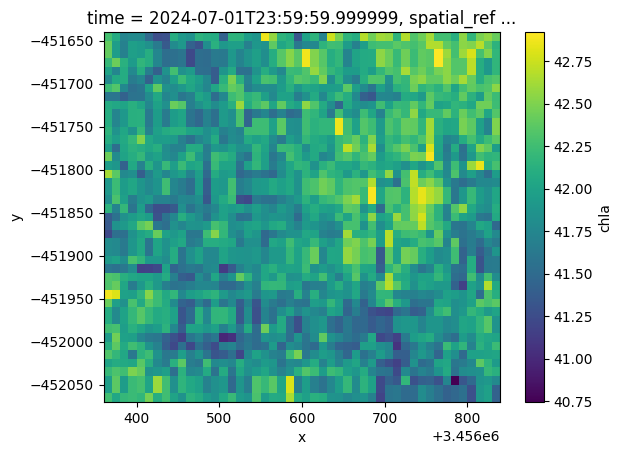

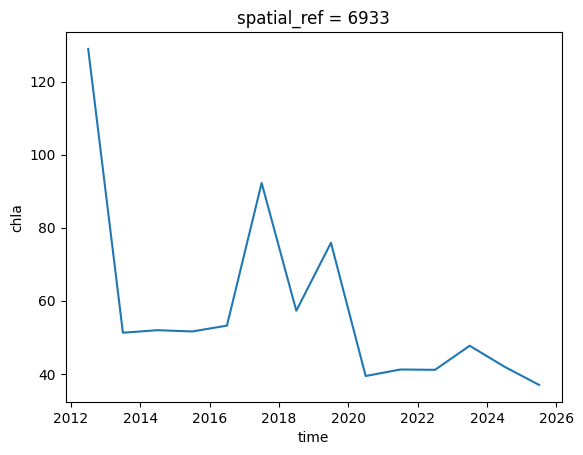

In [2002]:
i = 1
ds_annual.sel(time='2024-07',method='nearest').chla.plot()
plt.show()
ds_annual.chla.median(dim=('x','y')).plot()

In [2003]:
parameters

{'xyt': {'x': (35.82233, 35.8272),
  'y': (-3.54579, -3.54244),
  'time': ('2026-02-01', '2026-02-28')},
 'place': 'few_pixels',
 'grid_resolution': 10,
 'cell_area': 100,
 'resampling_option': 'nearest',
 'year1': 2017,
 'year2': 2026,
 'crs': 'EPSG:6933'}

#### 2 -- to --> 12 Monthly monitoring series 

In [2078]:
# --- parameters for monthly composites --- 
verbose = True
instruments_to_use = {
    'oli_agm'  : {'use': False },
    'oli'      : {'use': True},
    'msi_agm'  : {'use': False },
    'msi'      : {'use': True},
    'tm_agm'   : {'use': False },
    'tm'       : {'use': True},
    'tirs'     : {'use': True},  
    'wofs_ann' : {'use': False },
    'wofs_all' : {'use': False },  # wofs_all will be removed as it is better to derive from wofs_ann
    }

products = { 
                'tm_agm'  :["gm_ls5_ls7_annual"],
                'tm'      :["ls5_sr","ls7_sr"],
                'oli_agm' :["gm_ls8_annual","gm_ls8_ls9_annual"],
                'oli'     :["ls8_sr","ls9_sr"],
                'msi_agm' :["gm_s2_annual"],
                'msi'     :["s2_l2a"],
                'tirs'    :["ls5_st","ls7_st","ls8_st","ls9_st"],
                'wofs_ann':["wofs_ls_summary_annual"],
                'wofs_all':["wofs_ls_summary_alltime"],
               }

instruments_to_use = check_instrument_dates(instruments_to_use,
                           parameters['year1'],
                           parameters['year2'],False)


instruments,measurements,rename_dict = instruments_list(instruments_to_use) 
data_list = {}

In [2079]:
# --- set up a data frame to track progress
progress = pd.DataFrame(columns=('month','status'))
progress['month'] = months
progress['status']  = np.zeros(len(progress))


dict_keys(['oli', 'msi', 'tm', 'tirs'])

In [2006]:
progress

,month,status
0,2017-01,0.0
1,2017-02,0.0
2,2017-03,0.0
3,2017-04,0.0
4,2017-05,0.0
...,...,...
105,2025-10,0.0
106,2025-11,0.0
107,2025-12,0.0
108,2026-01,0.0


In [2086]:
# --- A 'function' that houses the steps to build a monthly time series --- 
# (global variables are relied upon)

def build_month_dataset(month,keep_all_vars=False)   :
        parameters['xyt']['time'] = \
            (month.start_time.strftime('%Y-%m-%d'), 
             month.end_time.strftime('%Y-%m-%d'))
        test = False
        if test: print(parameters['xyt']['time'])
        # --- build a month of data ---
        verbose  = False
        data_list             = build_dataset(parameters['xyt'],
                                                   instruments_to_use,
                                                   products,
                                                   measurements,
                                                   parameters['grid_resolution'],
                                                   parameters['resampling_option'],
                                                   rename_dict,
                                                   crs = parameters['crs'],
                                                   verbose = verbose)

        # --- drop empty datasets (this can happen esp for tm ) from the data list and from the instruments dictionary used to set WQ measures
        temp_instruments = instruments.copy()
        templist = list(data_list.keys())
        for instr in templist:
            if not 'time' in data_list[instr].sizes:
                print(f'.. no data found for {instr} ')
                del data_list[instr]
                del temp_instruments[instr]
        

        for inst in data_list.keys():
            if 'longitude' in data_list[inst].sizes.keys() :
                data_list[inst] = data_list[inst].rename({'longitude':'x','latitude':'y'})
        
        ds = add_vars_and_combine_datasets(data_list)
        ds = determine_water_area (ds,ds_annual)
        ds['water_5yr'] = ds_annual.sel({'time':ds.time},method='nearest').water_5yr.assign_coords({'time': ds.time})
        ds['water_ann'] = ds_annual.sel({'time':ds.time},method='nearest').wofs_ann_water.assign_coords({'time': ds.time})

        #qa_percent_threshold = 0.25
        #ds = ds.where(ds['data_qapass'] > qa_percent_threshold,drop=False)
        #gc.collect()

        ds = calc_ndvi(ds,ds.water_5yr,threshold=0)
        ds = calc_fai(ds,ds.water_5yr,threshold=0)
        ds = set_clearwater(ds,'fai','water_5yr','water_ann')

        # apply rayleigh correction
        ds = apply_R_correction(ds,['msi','oli','tm'],ds.clearwater,drop=True,test=False)

        print('running wq algorithms')
        algorithms_chla,algorithms_tsm = set_wq_algorithms(suffix='')
        dummy,tsm_vlist  = WQ_vars(ds.where(ds.clearwater).where(ds.qa_score>0),
                    algorithms_tsm,  
                    temp_instruments, 
                    new_dimension_name='tss_measure', 
                    new_varname=None, 
                    verbose=verbose,
                    test=False)
        # this two-step process avoids masking other variables
        ds[tsm_vlist] = dummy[tsm_vlist]
        del(dummy)
        gc.collect()

        dummy,chla_vlist = WQ_vars(ds.where(ds.clearwater).where(ds.qa_score>0),
                    algorithms_chla, 
                    temp_instruments, 
                    new_dimension_name='chla_measure', 
                    new_varname=None,
                    verbose=verbose,
                    test=False)
        ds[chla_vlist] = dummy[chla_vlist]
        del dummy
        gc.collect()    

        # condense to the key varibles 
        ds['chla'] = ds[chla_vlist].to_array(dim = 'chla_measure')
        ds['tss'] = ds[tsm_vlist]  .to_array(dim = 'tss_measure')

        # harmonise the data
        # --- remove bad variables which will otherwise cause problems with median, mean etc.
        for mmt  in np_data.loc[np_data.scale == 0].measurement.values:
            print('resetting to nan:', mmt)
            for var in 'tss','chla':
                if mmt in ds[var+'_measure']:
                    ds.loc[{var+'_measure' : mmt            }][var] = np.nan

        # Instrument to instrument harmonisation
        # loop through tss and chla data arrays withing the dataset...
        # loop through the variables in each case... 
        # assign revised values  back into the dataset 
        for mmt in 'tss','chla':
            vartype = mmt+'_measure'
            for varname in list(ds[vartype].values):
                ds[mmt].loc[{vartype :[varname]}]= \
                    harmonise_for_instrument(
                        ds[mmt].loc[{vartype :[varname]}],
                        varname,
                        lookup,
                        distributions,
                        test=False)

        # Variable to variable harmonisation
        # --- add the scale and offset parameters into the dataset for simplicity in the follwoing steps
        for var in ['chla','tss']:
            measures = ds[var+'_measure']
            for thing in ['scale','offset','era_factor']:
                ds[var+'_'+thing] = (var+'_measure'),np_data.set_index('measurement').loc[measures,thing]

        for var in ['tss','chla']:
            ds[var] = \
            (((ds[var] \
             * ds[var+'_scale']) \
             + ds[var+'_offset']) \
             * ds[var+'_era_factor'])\
        #    .clip(validrange[var][0],validrange[var][1])

        # calibrate each measurement to field data
        for var in ['tss','chla'] :
            for mmt in ds[var+'_measure'].values :
                choice = var
                if mmt == 'chla_tc2_msi': choice= mmt
                ds[var].loc[{var+'_measure' :  mmt}] = \
                    calibrate(ds[var].loc[{var+'_measure' :  mmt}],choice)


        # ------ calculate and harmonise the water colour (hue) -------
        ds['hue'] = ('time','y','x'),np.zeros([ds.time.size,ds.y.size,ds.x.size])*np.nan

        for instr in 'msi','oli','tm':
            if instr in ds.data_vars:
                ds['hue'] = xr.where(ds[instr]==1,
                hue_calculation(ds.where(ds[instr]==1).\
                                where(ds.qa_score > 0).
                                where(ds.clearwater==1)\
                                ,instr,verbose=True,test=True),
                ds.hue)

        # --- harmonise FAI, NDVI and Hue:
        for var in ['fai','ndvi','hue'] :
            for instr in 'msi','oli','tm':
                if instr in ds.data_vars and False:
                    ds[var].loc[ds[instr]==True] = \
                        harmonise_for_instrument(ds[var].loc[ds[instr]==True],
                                 var+'_'+instr,
                                 lookup,
                                 distributions)
    
        # --- estimate the OWT and save into a single variable
        ds = run_OWT(ds)
        ds['owt'] = ('time','y','x'), np.zeros((ds.sizes['time'],ds.sizes['y'],ds.sizes['x']))
        for instr in ['tm','oli','msi']:
            if instr in ds.data_vars:
                ds['owt'].loc[ds[instr]==True] = ds\
                    .where(ds.qa_score > 0)\
                    .where(ds.clearwater ==1)\
                    [instr+'_owt'].loc[ds[instr]==True]

        # trim temperatures to water areas
        for var in ['tirs_st' ,'tirs_st_qa','tirs_emis']:
            ds[var] = ds[var].where(
                (ds.clearwater==1)
                )    

        if not keep_all_vars:
            # reduce the tss and chla variables
            for var in 'tss','chla':
                ds[var] = ds[var].clip(validrange[var][0],validrange[var][1]).\
                    median(dim=var+'_measure')
            ds = ds.drop_dims(['tss_measure','chla_measure'])
        # capture information on the number of good observations
        month_obs_clear = ds_current\
                        .where(ds_current.clearwater==1)\
                        .where(ds_current.qa_score > 0)\
                        .qa_score\
                        .count(dim='time')
        month_obs_total = ds_current\
                        .where(ds_current.clearwater==1)\
                        .qa_score\
                        .count(dim='time')
        month_obs_percent = 100 * month_obs_clear.sum(dim=('x','y')) / month_obs_total.sum(dim=('x','y'))


        #save RGB for visualisation purposes
        ds['red']   = ds.msi04
        ds['green'] = ds.msi03
        ds['blue']  = ds.msi02
        keeplist  = [
            'red','green','blue',
            'tss','chla','ndvi','fai',
            'chla_tc2_msi',
            'tsm_lym_msi',
            'clearwater','water_5yr','water_ann',
            'hue','owt','tirs_st',
            'qa_score', #'data_coverage',
            #'msi','oli','tm',
            ]

    
        droplist = set(ds.data_vars) - set(keeplist)
        if not keep_all_vars  :        
            ds = ds.drop_vars(droplist)

        return(ds)
        

In [2088]:
over_write = False

In [2089]:
dataset_agm_filename

'/home/jovyan/deafrica_water_quality/WP21/datasets/WP21_few_pixels_agm.nc'

In [2092]:
    # --- build the monthly time series ---
monthly_dataset_filename = dataset_filename
if os.path.exists(monthly_dataset_filename)  and not over_write :
    ds_months = read_dataset(monthly_dataset_filename)
    start = False
else:
    start = True    
    # process the months...
    start = True
    for m in progress.month[:] :
        fname = scratch_directory+filename_base+m.start_time.strftime('%Y-%m')+'.nc'
        if True : print(fname)
        if os.path.exists(fname) and not over_write : ds_month = read_dataset(fname)
        else: 
            ds_month = build_month_dataset(m)
    
            # reduce on time (some  variables on the median, but other special cases)
            ds_month_res = ds_month\
                .where(ds_month.qa_score > 0)\
                .resample(time='ME').mean()
            ds_month_res['owt']           = ds_month.resample(time='ME').median().owt
            # -- capture the number of potential and actual observations of clear water
            ds_month_res['obs_clear']     = ds_month\
                            .where(ds_month.clearwater==1)\
                            .where(ds_month.qa_score > 0)\
                            .qa_score\
                            .resample(time='ME').count()
            ds_month_res['obs_total']     = ds_month\
                            .where(ds_month.clearwater==1)\
                            .qa_score\
                            .resample(time='ME').count()
    
            # --- the clearwater becomes a frequency estimate which might be used to weight the median value estimation
            ds_month_res['clearwater']    = ds_month.resample(time='ME').mean().clearwater       
            
            ds_month = ds_month_res
    
            ds_month.to_netcdf(fname)
        if start == True:
            print('start')
            start = False
            ds = ds_month
        else: 
            ds = ds.combine_first(ds_month)
        progress.loc[progress.month==m,'status']=100
        
    ds.to_netcdf(monthly_dataset_filename)
    ds_months = ds
print('\nMonthly dataset completed')


/home/jovyan/deafrica_water_quality/scratch/WP21_2017-01.nc
start
/home/jovyan/deafrica_water_quality/scratch/WP21_2017-02.nc
/home/jovyan/deafrica_water_quality/scratch/WP21_2017-03.nc
/home/jovyan/deafrica_water_quality/scratch/WP21_2017-04.nc
/home/jovyan/deafrica_water_quality/scratch/WP21_2017-05.nc
/home/jovyan/deafrica_water_quality/scratch/WP21_2017-06.nc
/home/jovyan/deafrica_water_quality/scratch/WP21_2017-07.nc
/home/jovyan/deafrica_water_quality/scratch/WP21_2017-08.nc
/home/jovyan/deafrica_water_quality/scratch/WP21_2017-09.nc
/home/jovyan/deafrica_water_quality/scratch/WP21_2017-10.nc
/home/jovyan/deafrica_water_quality/scratch/WP21_2017-11.nc
/home/jovyan/deafrica_water_quality/scratch/WP21_2017-12.nc
/home/jovyan/deafrica_water_quality/scratch/WP21_2018-01.nc
/home/jovyan/deafrica_water_quality/scratch/WP21_2018-02.nc
/home/jovyan/deafrica_water_quality/scratch/WP21_2018-03.nc
/home/jovyan/deafrica_water_quality/scratch/WP21_2018-04.nc
/home/jovyan/deafrica_water_qualit

In [2093]:
ds_months

<xarray.Dataset> Size: 32MB
Dimensions:       (time: 110, y: 43, x: 48)
Coordinates:
  * time          (time) datetime64[ns] 880B 2017-01-31 ... 2026-02-28
  * y             (y) float64 344B -4.516e+05 -4.517e+05 ... -4.521e+05
  * x             (x) float64 384B 3.456e+06 3.456e+06 ... 3.457e+06 3.457e+06
    spatial_ref   int32 4B 6933
Data variables: (12/18)
    qa_score      (time, y, x) float64 2MB 1.418e+04 1.418e+04 ... 1.882e+04
    tirs_st       (time, y, x) float64 2MB nan nan nan nan ... 24.41 24.41 24.4
    water_5yr     (time, y, x) float64 2MB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    water_ann     (time, y, x) float32 908kB 0.8788 0.8788 0.8788 ... 1.0 1.0
    ndvi          (time, y, x) float64 2MB 0.3565 0.3565 0.3541 ... nan nan nan
    fai           (time, y, x) float64 2MB 0.06473 0.06473 0.0644 ... nan nan
    ...            ...
    owt           (time, y, x) float64 2MB nan nan nan nan ... 1.0 1.0 1.0 1.0
    red           (time, y, x) float64 2MB 385.0 385.0 ... 1.068e+03 1.065e+03
    green         (time, y, x) float64 2MB 498.0 512.0 493.0 ... 832.0 830.0
    blue          (time, y, x) float64 2MB 358.0 361.0 366.0 ... 509.0 518.0
    obs_clear     (time, y, x) float64 2MB 0.0 0.0 0.0 0.0 ... 7.0 7.0 7.0 7.0
    obs_total     (time, y, x) float64 2MB 5.0 5.0 5.0 4.0 ... 14.0 14.0 14.0
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

In [1782]:
ds_months.time.sel(time='2023-04-30',method='nearest')

<xarray.DataArray 'time' ()> Size: 8B
array('2023-04-30T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time         datetime64[ns] 8B 2023-04-30
    spatial_ref  int32 4B 6933

In [2112]:
ds_202201 = build_month_dataset(months[months.start_time=='2022-01-01'].item(),keep_all_vars=True)

... instrument datasets complete

running wq algorithms


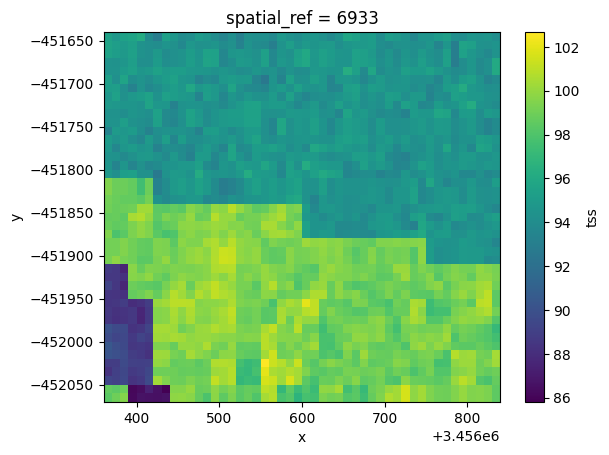

In [2116]:
ds_202201\
    .tss.median(dim='tss_measure').mean(dim='time').plot()

In [1879]:
def process_this_please(ds_in):
    # reduce the tss and chla variables
    for var in 'tss','chla':
        ds_in[var] = ds_in[var]\
            .median(dim=var+'_measure')
    #.clip(validrange[var][0],validrange[var][1])\
    ds_in = ds_in.drop_dims(['tss_measure','chla_measure'])
    
    
    
    ds_res = ds_in\
                    .where(ds_in.qa_score > 0)\
                    .resample(time='ME').mean()
    
    ds_res['owt']           = ds_in.resample(time='ME').median().owt
    # -- capture the number of potential and actual observations of clear water
    ds_res['obs_clear']     = ds_in\
                    .where(ds_in.clearwater==1)\
                    .where(ds_in.qa_score > 0)\
                    .qa_score\
                    .resample(time='ME').count()
    ds_res['obs_total']     = ds_in\
                    .where(ds_in.clearwater==1)\
                    .qa_score\
                    .resample(time='ME').count()
    
    # --- the clearwater becomes a frequency estimate which might be used to weight the median value estimation
    ds_res['clearwater']    = ds_in.resample(time='ME').mean().clearwater       
    
    return(ds_res)
    



In [2117]:
ds_daily = ds_202201
df = pd.DataFrame(ds_daily.tss_measure)
df['tss'] = ds_daily.median(dim=('x','y')).mean(dim='time')['tss']
df

,0,tss
0,ndssi_rg_msi,60.658000
1,ndssi_rg_oli,35.044861
2,ndssi_rg_tm,52.877256
3,ndssi_bnir_oli,22.869412
4,ti_yu_oli,36.614148
5,ti_yu_tm,33.464149
6,tsm_lym_oli,72.088859
7,tsm_lym_msi,70.893512
8,tsm_lym_tm,73.447692
9,tss_grb_msi,141.699501


In [2108]:
ds_res = process_this_please(ds_202508.copy())

In [2109]:
var = 'tss'
ds_res\
    .where(ds_months.obs_average > 1)\
    [var]\
    .where(ds_res.clearwater==1)\
    .median(dim=('x','y'))

<xarray.DataArray 'tss' (time: 1)> Size: 8B
array([116.7331803])
Coordinates:
  * time         (time) datetime64[ns] 8B 2025-08-31
    spatial_ref  int32 4B 6933
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

In [1714]:
# --- patch up attributes for temperature
ds_current['tirs_st'].attrs.update({'units' : 'degree Celsius'})

ds_months['tirs_st'].attrs.update({'units' : 'degree Celsius'})

In [2095]:
full_datasets = {'ann':ds_annual,'months':ds_months}

In [2101]:
#subset on time
ds_months = full_datasets['months']
ds_annual = full_datasets['ann']
ds_months = ds_months.sel(time=slice('2025-05-01','2026-03-01'))
ds_annual = ds_annual.sel(time=slice('2024-05-01','2026-03-01'))

In [2103]:
# pull out some specifics
ds_months.sel(time='2025-08-30',method='nearest').median(dim=('x','y')).tss

<xarray.DataArray 'tss' ()> Size: 8B
array(116.7331803)
Coordinates:
    time         datetime64[ns] 8B 2025-08-31
    spatial_ref  int32 4B 6933
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

#### .... check  results

In [1766]:
%run /home/jovyan/dev/deafrica_water_quality/WP1.2/_WQ_functions.py


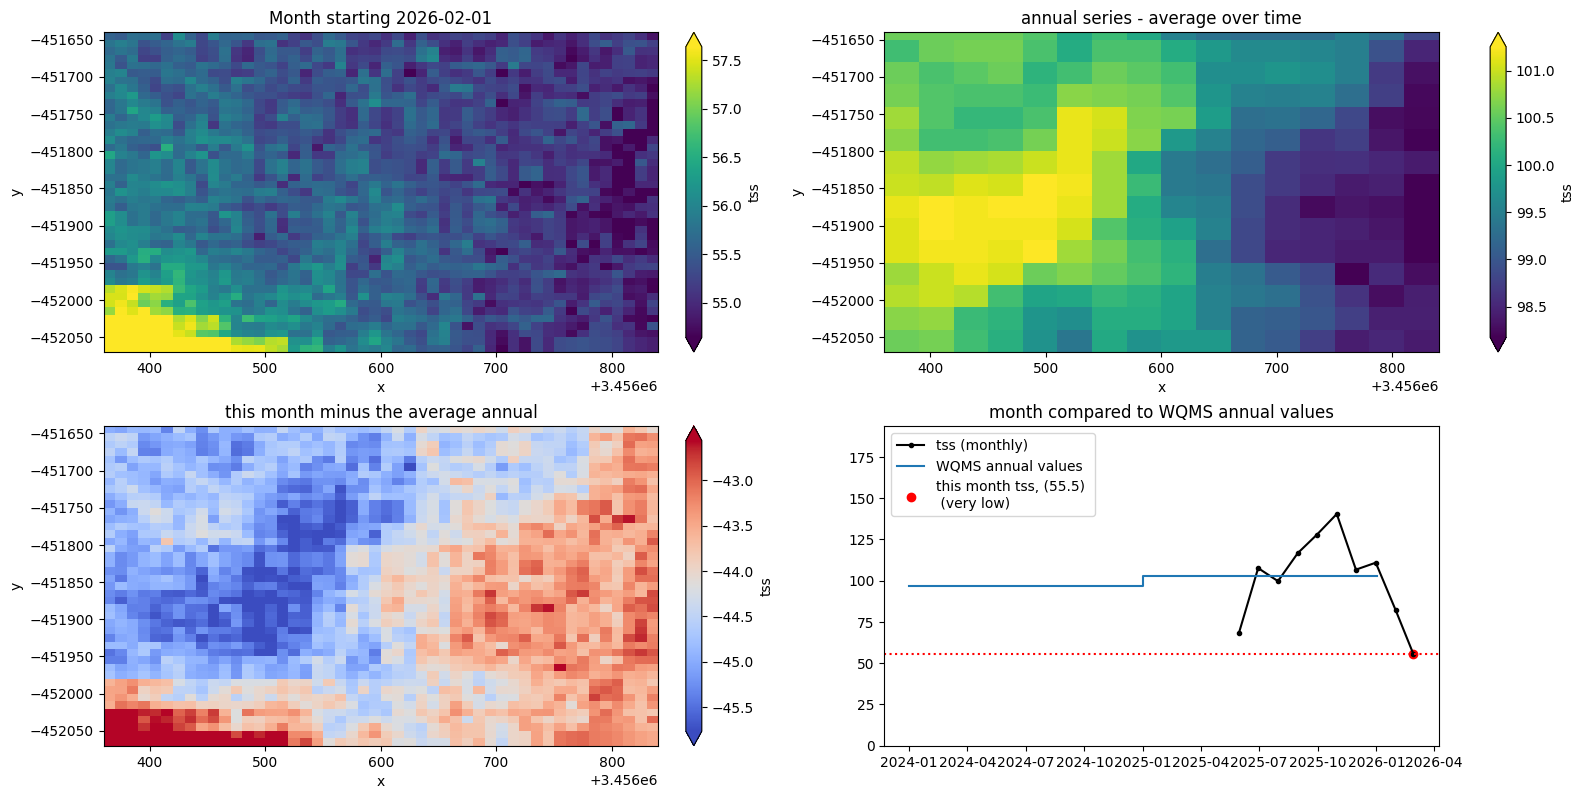

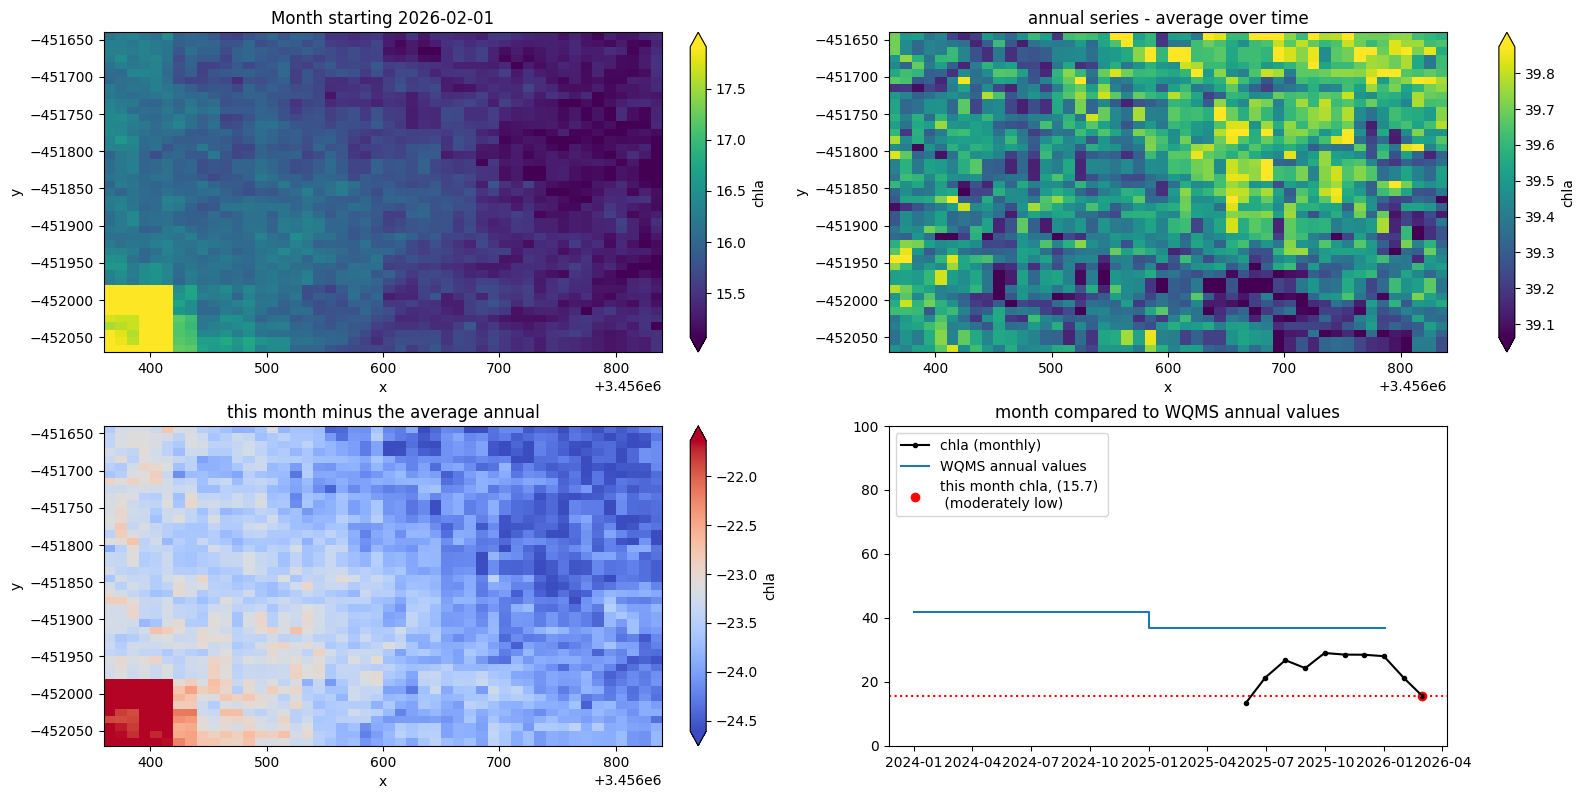

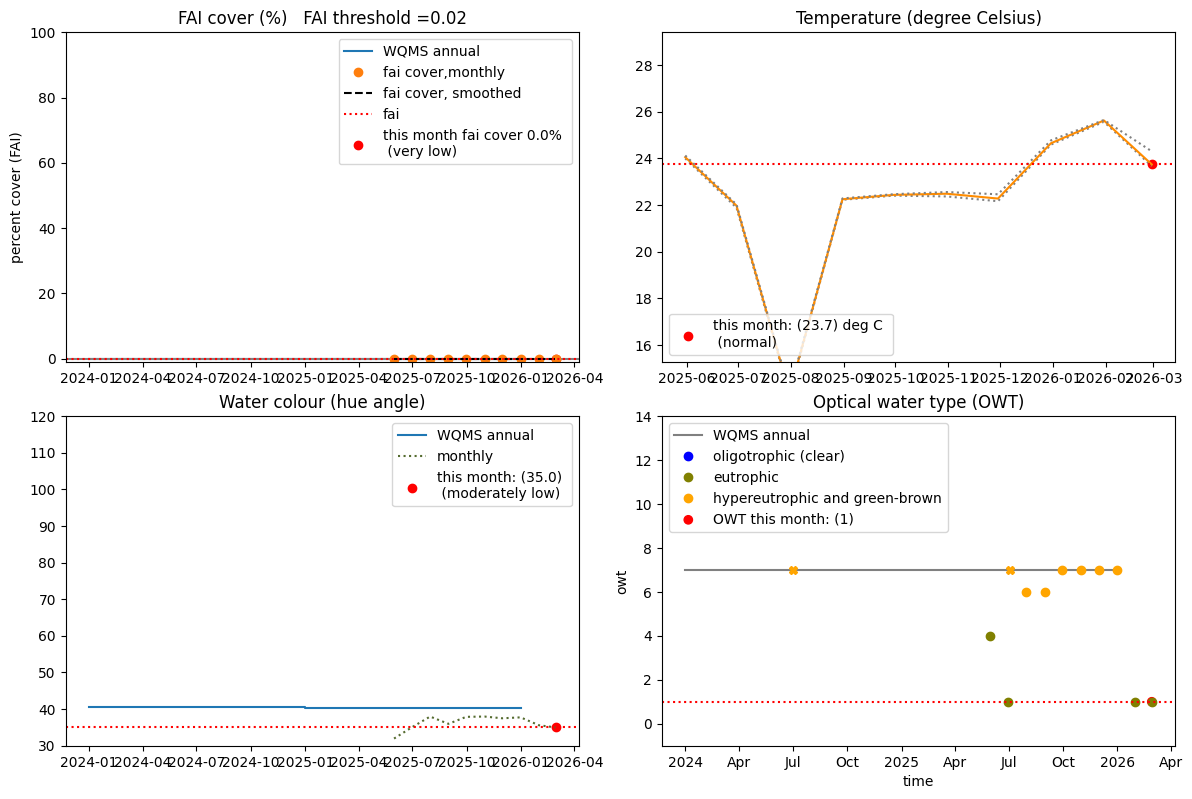

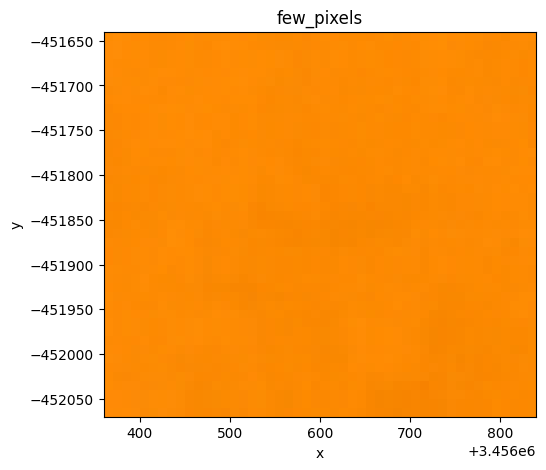

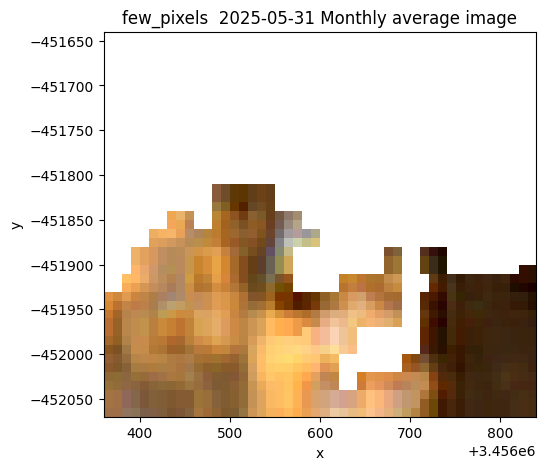

In [2102]:
# plot results
# pull out a single month but retain the time dimension for compatibility...
# 
# some value descriptors based on quantiles
ds_months['obs_percent'] = ds_months.obs_clear.sum(dim=('x','y')) / ds_months.obs_total.sum(dim=('x','y'))
ds_months['obs_average'] = ds_months.obs_total.mean(dim=('x','y'))

Q = np.arange(0,1.1,.1)
data = np.array([
    ('very low',0),
    ('low',.01),
    ('low',.1),
    ('moderately low',.11),
    ('moderately low',.2),
    ('normal',.21),
    ('normal',.79),
    ('moderately high',.8),
    ('moderately high',.89),
    ('high',.9),
    ('high',.99),
    ('very high',1),
    ])
Qforlabels   = data[:,1]
descriptions = data[:,0]

# --- this is a convenience for plotting
clearwater = ds_months.clearwater>0.5
clearwater = ds_months.clearwater>0.2
reference_mmt = {'tss':'tsm_lym_msi' ,
                  'chla': 'chla_tc2_msi'}
showref = False
showthismonth = True
showmonths = True
showsmooth = False
ds_month = ds_months.isel(time=slice(ds_months.time.size-1,ds_months.time.size))
for var in 'tss','chla' :
    s = ''
    vminmax = {'tss': (00,200,0,40),
               'chla' : (0,150,0,40) }
    yminmax = {'tss':   (0,1.5 * ds_months.tss.quantile(0.9)),
               'chla' : (0,100) }
    
    fig, axes = plt.subplots(2,2,sharex=False, sharey=False, layout="constrained")    
    cm = 1/2.54
    fig.set_size_inches(40*cm,20*cm)

    axis = axes[0,0]
    ds_month[var+s].\
        mean(dim='time').\
        plot(ax=axis,
             robust=True,
             #vmin=vminmax[var][0],vmax=vminmax[var][1],
            )
    axis.set_title(f'Month starting {months[months.size-1].start_time.strftime('%Y-%m-%d')}')

    axis = axes[0,1]
    ds_annual[var+s].\
        mean(dim='time').plot(ax=axis,robust=True,
                             # vmin=vminmax[var][0],vmax=vminmax[var][1],
                             )
    axis.set_title('annual series - average over time')

    axis = axes[1,0]
    ((ds_month\
        .where(ds_month.clearwater > 0.5)\
        .where(ds_month.obs_average > 1)\
        [var+s].\
        mean(dim='time')) - (ds_annual[var+s].mean(dim='time')))\
        .plot(ax=axis,
              robust=True,
              cmap='coolwarm',
              #vmin= 0.5 * -np.mean(vminmax[var][0:2]), vmax= 0.5 *  np.mean(vminmax[var][0:2]),
             )
    axis.set_title('this month minus the average annual')
    
    axis = axes[1,1]
    ref_var = reference_mmt[var]
    axis.set_ylim(yminmax[var][0],yminmax[var][1])
    if showref : axis.plot(
        ds_months.time,
        ds_months\
            .where(ds_months.obs_average > 1)\
            [ref_var]\
            .where(clearwater)\
            .median(dim=('x','y')),
        linestyle='',
        marker='.',
        label = f'{ref_var} (reference measurement) (monthly)',
        c='k',
    )
    if showmonths :
        v = ds_months\
                .where(ds_months.obs_average > 1)\
                [var]\
                .where(clearwater)\
                .median(dim=('x','y'))
        if showsmooth : 
                axis.plot(
                ds_months.time,
                v,
                linestyle='',
                marker='o',
                label = f'{var} (monthly)',
                c='gray')    
        else: 
            axis.plot(
                ds_months.time,
                v,
                linestyle='-',
                marker='.',
                label = f'{var} (monthly)',
                c='k')
        
        if showsmooth : 
            x,y = smoothed_series(ds_months.time,piecewise_linreg(ds_months.time.astype('float'),v)[0][1])
            axis.plot(x,y,
                        linestyle='--',
                        color ='k',
                        label=f'{var}, smoothed',
                        )

    t,y = make_stepplot_data(
            ds_annual.time,
            ds_annual[var+s].median(dim=('x','y')))
    axis.plot(t,y,
        label='WQMS annual values',
        linestyle = '-',
        marker='')
    if showthismonth: 
        month_median = ds_month[var+s].\
            where(clearwater).\
            mean(dim='time').\
            median(dim=('x','y')).values.round(1).item()
        axis.axhline(
            month_median,
            linestyle=':',
            c='r',
            label='')
        
        description  = descriptions[np.argmin(abs(ds_months[var].median(dim=('x','y')).quantile(Qforlabels).values - month_median))]
    
        axis.scatter(
            ds_month.time[0],month_median,
            #linestyle='-',
            marker='o',
            c='r',
            label=f'this month {var+s}, ({month_median}) \n ({description})')
                                                            
                                                        
    axis.legend(loc='upper left')
    axis.set_title('month compared to WQMS annual values')
    plt.savefig(results_directory+f'monitor_results_{placename}_{var}_fig1.pdf',format='pdf')
    plt.show()

#------------------------------------------------------------------------------------------
# other variables
# ------------------
fig, axes = plt.subplots(2,2,sharex=False, sharey=False, layout="constrained")    
cm = 1/2.54
fig.set_size_inches(30*cm,20*cm)

# ---- FAI ---
var = 'fai'
s = ''
axis = axes[0,0]
fai_threshold = 0.02
axis.set_ylim(-1,100)

agm_fai_cover = 100 * \
    (
    ds_annual.       agm_fai.where(ds_annual.agm_fai>0.01).       count(dim=('x','y')) / \
    ds_annual.wofs_ann_water.where(ds_annual.wofs_ann_water>0).count(dim=('x','y'))
    )

t,y = make_stepplot_data(
      ds_annual.time,
      agm_fai_cover)
axis.plot(t,y,
        label='WQMS annual',
        linestyle = '-',
        marker='')

axis.axhline(0,linestyle='-',c='gray')
fai_cover = \
    (100*   ds_months.where(ds_months.fai>fai_threshold).fai.count(dim=('x','y')) /\
            ds_months.where(ds_months.water_5yr>0).water_5yr.count(dim=('x','y'))   )
axis.plot(
    ds_months.time, fai_cover, 
    linestyle='',
    marker='o',
    label='fai cover,monthly',
    )

v = fai_cover
x,y = smoothed_series(ds_months.time,piecewise_linreg(ds_months.time.astype('float'),v)[0][1])
axis.plot(x,y,
        linestyle='--',
        color ='k',
        label='fai cover, smoothed',
        )

axis.set_ylabel('percent cover (FAI)')
axis.set_title('FAI cover (%)   FAI threshold ='+str(fai_threshold))
showndvi = False
if showndvi : 
    axis.plot(
        ds_months.time, 
        (100*ds_months.where(ds_months.clearwater>0).ndvi.mean(dim=('x','y'))),
        linestyle=':',
        label= f'mean ndvi * 100',
        )
    axis.set_ylabel('percent cover (FAI)')
    axis.set_title('FAI cover (%), and,  NDVI mean.   FAI threshold ='+str(fai_threshold))


if showthismonth:
    month_cover  = fai_cover[fai_cover.time==ds_month.time.values].round(1).item()
    description  = descriptions[np.argmin(abs(fai_cover.quantile(Qforlabels).values - month_cover))]
    axis.axhline(                  month_cover, linestyle=':', c='r', label=''+var+s)
    axis.scatter(ds_month.time[0], month_cover, linestyle='-', c='r', label=f'this month {var} cover {month_cover}% \n ({description})')

axis.legend(loc='best')

# ------ temperature ----
Q = (.2,.5,.8)
axis = axes[0,1]

axis.axhline(0,linestyle='-',c='gray')
monthly_temps = ds_months.tirs_st.quantile(Q,dim=('x','y'))
ymin = ymax =  monthly_temps.loc[{'quantile' : Q[1]}].mean() 
r = \
    ( monthly_temps.loc[{'quantile' : Q[2]}].max() - \
      monthly_temps.loc[{'quantile' : Q[0]}].min() ) * 0.6
ymin,ymax = ymin-r,ymax+r
axis.set_ylim(ymin,ymax)

for percentile in Q:
    s = ':'; c = 'gray'
    if percentile == .5 : 
        s = '-';c='darkorange'
    axis.plot(monthly_temps.time, 
        ds_months.tirs_st.quantile(Q,dim=('x','y')).loc[{'quantile' : percentile}], 
        #label=f'{percentile*100} percentile' ,
        linestyle=s ,
        c = c  )
month_temp = monthly_temps.loc[{'quantile' : .5}][monthly_temps.time==ds_month.time.values] 

description  = descriptions[np.argmin(abs(monthly_temps.loc[{'quantile' : .5}].quantile(Qforlabels).values - month_temp.values))]
axis.axhline(                  month_temp, linestyle=':', c='r', label='')
axis.scatter(ds_month.time[0], month_temp, 
             linestyle='-', c='r', 
             label=f'this month: ({month_temp.values.round(1).item()}) deg C \n ({description})')
axis.set_title('Temperature (degree Celsius)')
axis.legend(loc='lower left')

# ---- hue ----
axis = axes[1,0]
#monthly_hue = ds_months.hue.quantile(.5,dim=('x','y'))
monthly_hue = ds_months.hue.quantile(.5,dim=('x','y'))
month_hue   = monthly_hue[monthly_hue.time==ds_month.time.values].values.round(0).item()
axis.set_ylim(30,120)

t,y = make_stepplot_data(
      ds_annual.time,
      #ds_annual['agm_hue'].median(dim=('x','y')))
      ds_annual['agm_hue'].mean(dim=('x','y')))
axis.plot(t,y,
        label='WQMS annual',
        linestyle = '-',
        marker='')

axis.plot(
        monthly_hue.time,
        monthly_hue,
        linestyle=':',color='darkolivegreen',
        label=f'monthly') 

description  = descriptions[np.argmin(abs(monthly_hue.quantile(Qforlabels).values - month_hue))]

axis.axhline(                  month_hue, linestyle=':', c='r', label='')
axis.scatter(ds_month.time[0], month_hue, 
             linestyle='-', c='r', 
             label=f'this month: ({month_hue}) \n ({description})')
axis.legend(loc='best')
axis.set_title('Water colour (hue angle)')


# ----- owt-----
axis = axes[1,1]

owtypes = {
    'oligo' : ([3,9,13],'blue','oligotrophic (clear)'),
    'eutro' : ([1,2,4,5,11,12],'olive','eutrophic'),
    'heutr' : ([6,7,8,10],'orange','hypereutrophic and green-brown')
}

monthly_owt = ds_months\
    .where(ds_months.owt != 0)\
    .where(clearwater)\
    .owt.quantile(.5,dim=('x','y')).astype('int')

month_owt   = monthly_owt[monthly_owt.time==ds_month.time.values].values.item()

axis.set_ylim(-1,14)

annual_owt = ds_annual['msi_agm_owt'].median(dim=('x','y')).astype('int')

t,y = make_stepplot_data(ds_annual.time, annual_owt )
plt.plot(t,y,  label='WQMS annual', linestyle = '-', marker='',c='gray')

for owt in owtypes.keys():
    annual_owt\
        .where(annual_owt.isin(owtypes[owt][0]))\
        .plot(
            marker='X',
            color=owtypes[owt][1],
            linestyle='',
            #label=f'{owtypes[owt][2]}'
            )
    monthly_owt\
        .where(monthly_owt.isin(owtypes[owt][0]))\
        .plot(
            marker='o',
            color=owtypes[owt][1],
            linestyle='',
            label=f'{owtypes[owt][2]}',
            ax = axis
        )


if showthismonth:
    axis.axhline(                  month_owt, linestyle=':', c='r', label='')
    axis.scatter(ds_month.time[0], month_owt, 
                 linestyle='', 
                 c='r', 
                 marker='o', 
                 label=f'OWT this month: ({month_owt})')
plt.legend(loc = 'upper left')


axis.set_title('Optical water type (OWT)')

plt.savefig(f'{results_directory}monitor_results_{placename}_fig2.pdf',format='pdf')

rgb(ds_annual.sel(time='2025-06-01',method='nearest'),size=5)
plt.title(placename)
plt.savefig(f'{results_directory}monitor_results_{placename}_fig3.pdf',format='pdf')
plt.show()

mon = '2025-06'
rgb(ds_months.sel(time=mon,method='nearest'),size=5)
mon = ds_months.time.sel(time=mon,method='nearest').dt.date.values
plt.title(f'{placename}  {mon} Monthly average image')
plt.savefig(f'{results_directory}monitor_results_{placename}_fig4.pdf',format='pdf')
plt.show()




## End

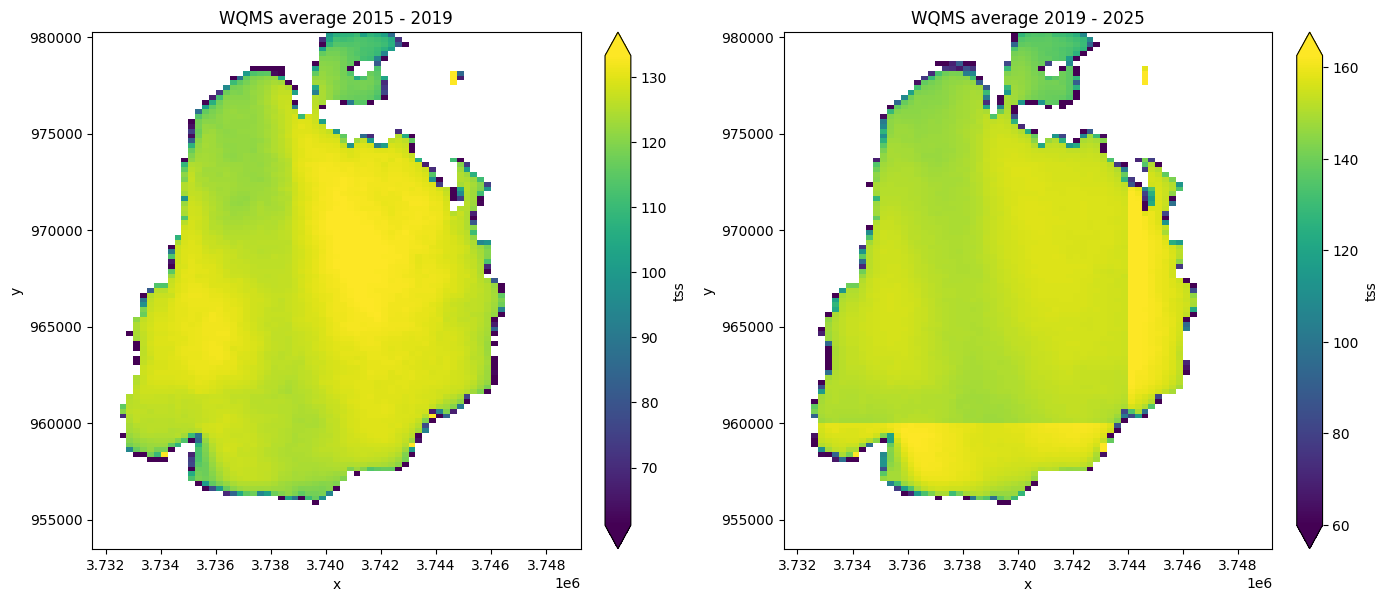

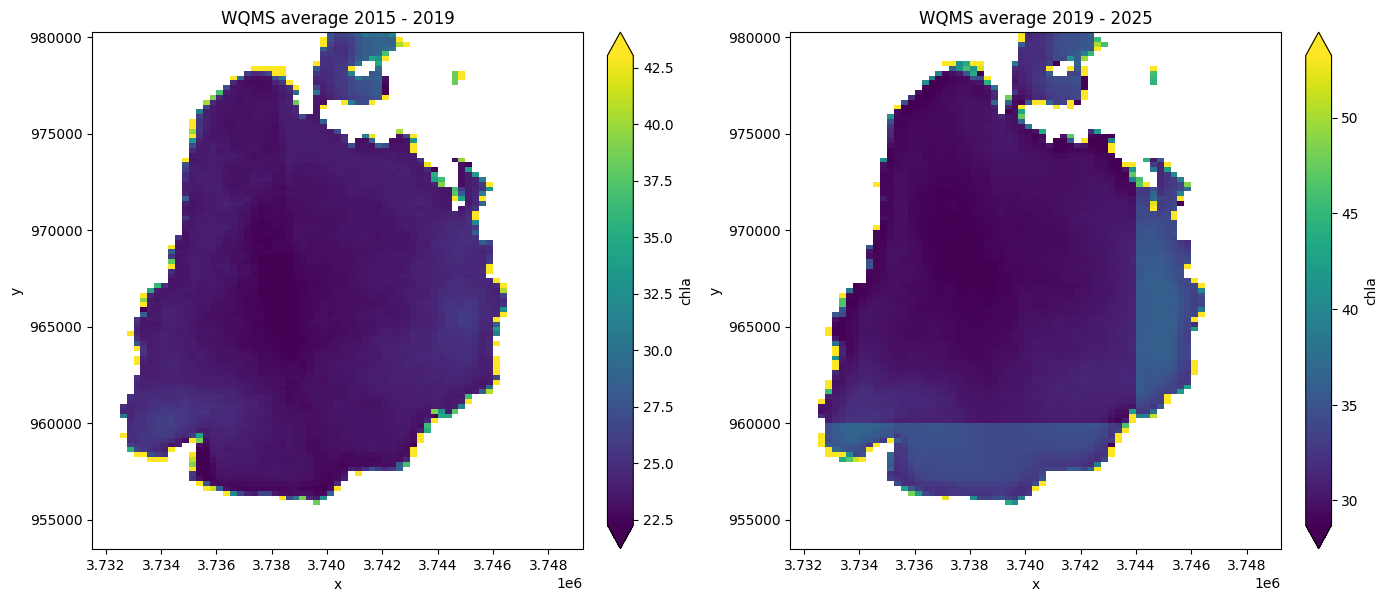

In [1357]:
for var in 'tss','chla' :

    s = ''
    vminmax = {'tss': (00,80,0,40),
               'chla' : (20,80,0,40) }
    yminmax = {'tss':   (0,1.5 * ds_months.tss.quantile(0.9)),
               'chla' : (0,100) }
    colours = {'tss' : 'viridis', 
               'chla' : 'viridis' }

        
    fig, axes = plt.subplots(1,2,sharex=False, sharey=False, layout="constrained")    
    cm = 1/2.54
    fig.set_size_inches(35*cm,15*cm)

    axis = axes[0]
    ds_annual[var+s]\
        .sel(time=slice('2015-01-01','2019-12-31'))\
        .mean(dim='time')\
        .plot(ax=axis,robust=True,
              cmap = colours[var],
                             # vmin=vminmax[var][0],vmax=vminmax[var][1],
                             )
    axis.set_title('WQMS average 2015 - 2019')

    axis = axes[1]
    ds_annual[var+s]\
        .sel(time=slice('2019-12-31','2026-01-01'))\
        .mean(dim='time')\
        .plot(ax=axis,robust=True,
              cmap = colours[var],
              
                             # vmin=vminmax[var][0],vmax=vminmax[var][1],
                             )
    axis.set_title('WQMS average 2019 - 2025')


                                                            
                                                        
    plt.savefig(results_directory+f'monitor_results_{placename}_{var}_image.pdf',format='pdf')
    plt.show()


In [1373]:
ds_annual

<xarray.Dataset> Size: 87MB
Dimensions:              (time: 21, y: 107, x: 71)
Coordinates:
  * time                 (time) datetime64[ns] 168B 2005-07-02T11:59:59.99999...
  * y                    (y) float64 856B 9.801e+05 9.799e+05 ... 9.536e+05
  * x                    (x) float64 568B 3.732e+06 3.732e+06 ... 3.749e+06
    spatial_ref          int32 4B 6933
Data variables: (12/104)
    oli05_agm            (time, y, x) float64 1MB nan nan ... 2.889e+03 2.89e+03
    oli06_agm            (time, y, x) float64 1MB nan nan ... 3.224e+03
    oli07_agm            (time, y, x) float64 1MB nan nan ... 2.356e+03
    oli_agm_smad         (time, y, x) float32 638kB nan nan ... 0.003 0.003177
    oli_agm_emad         (time, y, x) float32 638kB nan nan nan ... 577.0 586.0
    oli_agm_bcmad        (time, y, x) float32 638kB nan nan ... 0.04911 0.04999
    ...                   ...
    chla_modis2b_tm      (time, y, x) float32 638kB nan nan nan ... nan nan nan
    chla                 (time, y, x) float64 1MB nan nan nan ... nan nan nan
    tss                  (time, y, x) float64 1MB nan nan nan ... nan nan nan
    red                  (time, y, x) float32 638kB nan nan ... 1.225e+03
    green                (time, y, x) float32 638kB nan nan ... 1.087e+03
    blue                 (time, y, x) float32 638kB nan nan nan ... 912.0 705.0
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

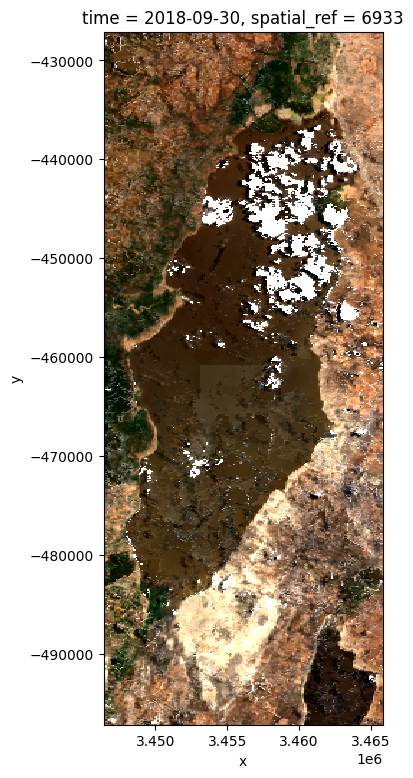

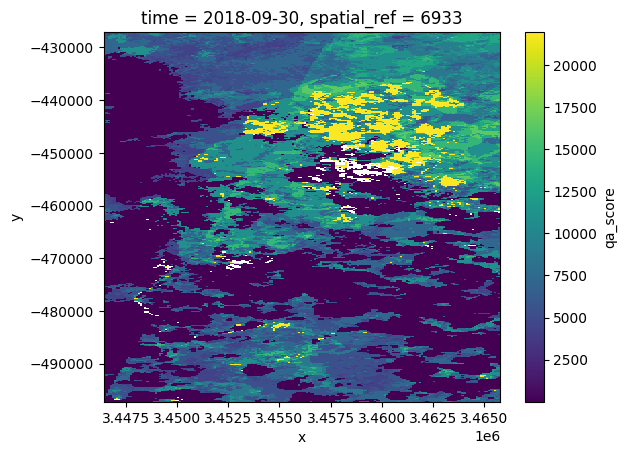

In [1389]:
i = i +1
rgb(ds_months\
    .where(ds_months.qa_score > 0)\
    .isel(time=i),robust=True,size=9,aspect=0.4)
plt.show()
ds_months.isel(time=i).qa_score.plot()

In [844]:
cell_km = pow(cellsize,2)*np.cos((ymax+ymin)/2 * np.pi/180) / 1000000

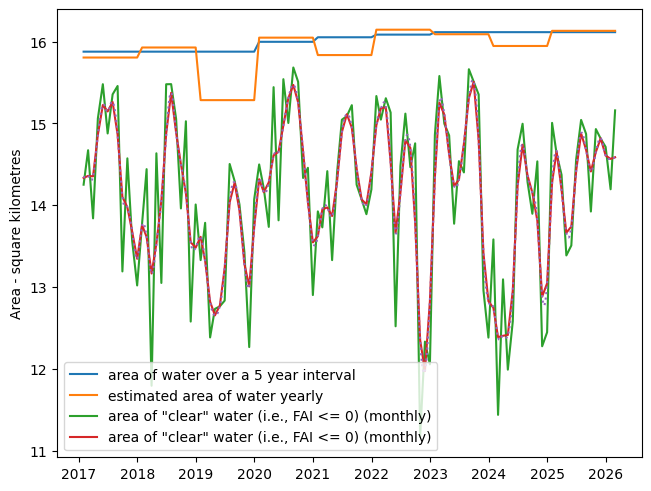

In [845]:
fig, axes = plt.subplots(1,1,sharex=False, sharey=False, layout="constrained") 
axis = axes
cell_km * ds_months.where(ds_months.clearwater==1).clearwater.count(dim=('x','y'))

water_area_5yr = cell_km * ds_months.where(ds_months.water_5yr>0.5).water_ann.count(dim=('x','y'))
water_area_ann = cell_km * ds_months.where(ds_months.water_ann>0.5).water_ann.count(dim=('x','y'))
clearwater_area = ds_months.where(ds_months.water_5yr==True).clearwater.mean(dim=('x','y')) * water_area_ann
axis.plot(ds_months.time,water_area_5yr,label='area of water over a 5 year interval')
axis.plot(ds_months.time,water_area_ann,label='estimated area of water yearly')
axis.plot(ds_months.time,clearwater_area,label='area of "clear" water (i.e., FAI <= 0) (monthly)')
axis.plot(ds_months.time,
          piecewise_linreg(ds_months.time.astype('float'),clearwater_area)[0][1],
          label='area of "clear" water (i.e., FAI <= 0) (monthly)')
tlist = ds_months.time
ylist = piecewise_linreg(ds_months.time.astype('float'),clearwater_area)[0][1]
x,y = smoothed_series(ds_months.time,piecewise_linreg(ds_months.time.astype('float'),clearwater_area)[0][1])
axis.plot(x,y,linestyle=':')

axis.set_ylabel('Area - square kilometres')
axis.legend()
plt.show()
#axis.plot(water_area_5yr)

Text(0.5, 1.0, 'Loskop_Dam  2025-05-31 Monthly average image')

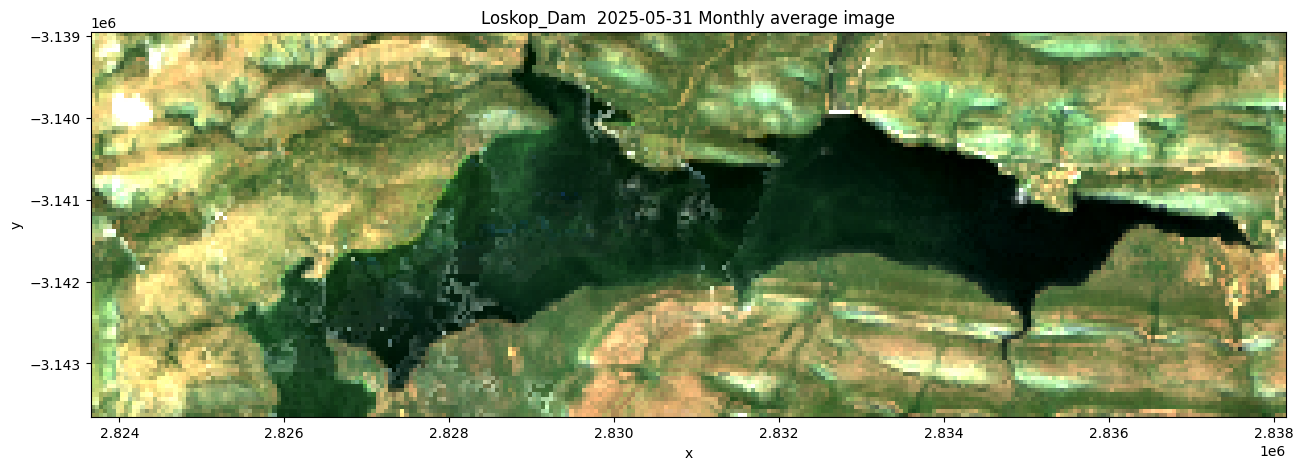

In [946]:
mon = '2025-06'
rgb(ds_months.sel(time=mon,method='nearest'),size=5)
mon = ds_months.time.sel(time=mon,method='nearest').dt.date.values
plt.title(f'{placename}  {mon} Monthly average image')


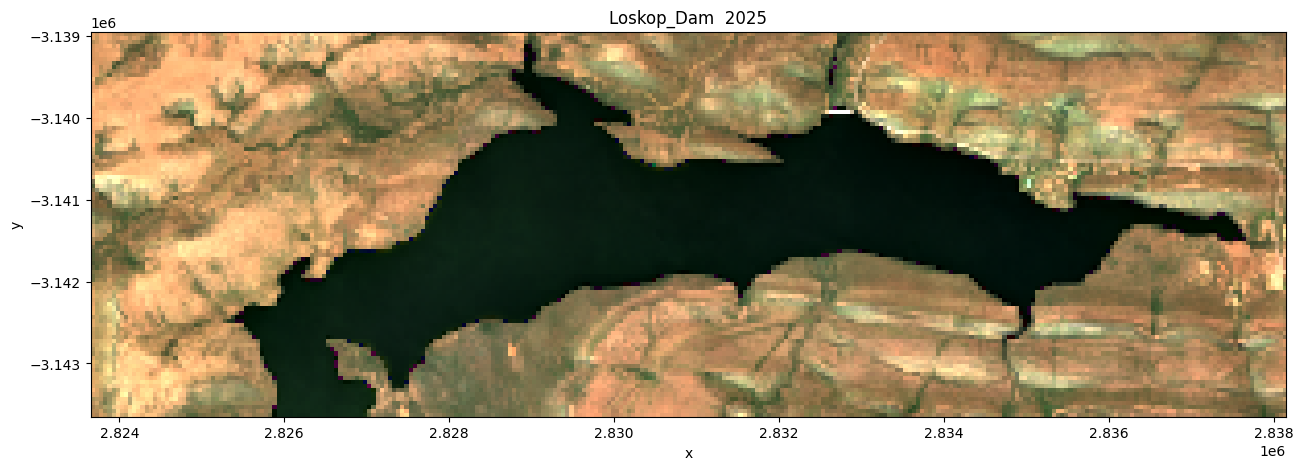

### Filter outliers  - retaining this material here for now (methods are new and I don't want to lose them)

#### Rather than rely Entirely on pq channels to detect clouds etc., we can use the geomedians and mads as a reference. 

The deviation of each data point from the geomedian is compared mean absolute deviation using two indepenent tests.
Outliers are identified by refence to a combined threshold, and flagged with a continuous variable qa_score such that:
- 0 > qa_score    : implies an outlier.
- 0 < qa_score <= 1:  implies data that are to be expected in the data given the geomedian and MAD values.

All outliers are retained in the dataset. Outliers with plausible spectral reflectances indicate change. They are used in the identification of floating photosynthetic material such as water hyacinth.

Datasets with a large percentage of outliers may be rejected as unreliable.

For any given year, only one geomedian is produced (e.g., a Landsat TM geomedian is not produced in years when OLI is available). In these situations the TM data is compared to the OLI geomedian with good results. 


### Calculate QA scores. 
#### Note that negative values that may be produced if an offset is subtracted from MSI data will lead to data failing qa tests.
see the functions in QA_functions.ipynb for commentary

In [59]:
# Set agm_tests,  the variables to be used in the QA analysis:


agm_tests   =   geomedian_test_bands()

# --- Calculate QA scores  ( re-worked to simplify / streamline and save memory through calling the qa tests once for each time index)
# --- This is fiddly because each instrument needs to be handled differently (the end result being a common qa_score)

# --- Set thresholds. These are based on experimentation. If the combined deviation is less than the threshold the qa_score will be > 0
# ---- the value of 1.4 is about the equivalent of one standard deviation (literature says 1.48 for a normal distribution)
thresholds = {}
thresholds['oli']  = 1.4 * 2   # this seems best ...
thresholds['msi']  = 1.4 * 2   # this seems best ...
thresholds['tm']   = 1.4 * 2   # could permit a higher threshold for tm v oli ... permitting more sensor variation ...

rsad_factor    = 0.4   # --- allow more variation in spectral angle than in brightness when calculating the combined QA measure

# --- initiate a dictionary to hold the datasets for each sensor, until they can be combined ---
datasets = None
for instr in list(('msi','oli','tm')):
    
    if instr in data_list.keys():        
        # --- the statistic to be used to normalise to 'relative' deviations
        bcmad_var = instr+'_agm_bcmad'
        smad_var  = instr+'_agm_smad'

        # --- set the specific combination of bands to be used for the qa tests
        if instr == 'msi' : 
                data_band_list      = agm_tests['msi-v-msi_agm-noIRband']['msi']
                geomedian_band_list = agm_tests['msi-v-msi_agm-noIRband']['msi_agm']
        if instr == 'oli' : 
                data_band_list      = agm_tests['oli-v-oli_agm-noIRband']['oli']
                geomedian_band_list = agm_tests['oli-v-oli_agm-noIRband']['oli_agm']
        if instr == 'tm' : 
            data_band_list      = agm_tests['tm-v-tm_agm-noIRband']['tm']
            geomedian_band_list = agm_tests['tm-v-tm_agm-noIRband']['tm_agm']
            start_year           = int(data_list[instr].time[0].dt.year.item()) # returns the year of the earliest obs from this sensor
            if start_year > 2012 :  #special case since tm geomedian not available after 2012 - compare with the oli agm instead
                data_band_list      = agm_tests['tm-v-oli_agm-noIRband']['tm']
                geomedian_band_list = agm_tests['tm-v-oli_agm-noIRband']['oli_agm']
                bcmad_var           = 'oli_agm_bcmad'
                smad_var            = 'oli_agm_smad'
        
        # --- set up the dataset and create new variables to receive the qa data
        #     notice that at this point we drop the reference to the instrument (instrument-agnostic)
        ds_instr = data_list[instr]
        ralb     = 'qa_ralb'
        alb      = 'qa_alb'
        sizes    = ds_instr.sizes
        ds_instr[ralb] = ('time','y','x'), np.ones((sizes['time'],sizes['y'],sizes['x']))
        ds_instr[alb]  = ('time','y','x'), np.ones((sizes['time'],sizes['y'],sizes['x']))
        
        # --- iterate through the time domain to process 
        for t in ds_instr.time :
            gm_year = str(t.dt.year.item())  # take geomedian from this year
    
            ds_instr[ralb].loc[{'time':t}] = \
                relative_albedo(
                    data                = ds_instr.loc[{'time':t}],
                    geomedian           = ds_annual.sel(time=gm_year,method = 'nearest').squeeze(),
                    data_band_list      = data_band_list,
                    geomedian_band_list = geomedian_band_list,
                    mad_var             = bcmad_var,            
                    verbose             = False,
                    test                = False) 
    
        # --- compensate for not including the IR bands ---
        ds_instr[ralb] = 6/4 *     ds_instr[ralb]
        ds_instr[alb]  = 6/4 *     ds_instr[alb] 
    
        # --- process for the relative spectral angle --- 
        rsad           = 'qa_rsad'
        sad            = 'qa_sad'
        ds_instr[rsad] = ('time','y','x'), np.ones((sizes['time'],sizes['y'],sizes['x']))

        # --- iterate through the time domain to process 
        for t in ds_instr.time :
            gm_year = str(t.dt.year.item())  # take geomedian from this year
    
            ds_instr[rsad].loc[{'time':t}] = \
                relative_spectral_angle_deviation(
                    data                = ds_instr.loc[{'time':t}],
                    geomedian           = ds_annual.sel(time=gm_year,method='nearest').squeeze(),
                    data_band_list      = data_band_list,
                    geomedian_band_list = geomedian_band_list,
                    mad_var             = smad_var,            
                    verbose             = False,
                    test                = False) 

        # --- combine ralb and rsad, allowing more variation in the spectral angle than in the albedo
        #     the raw qa is the magnitude of the vector [rsad,ralb] assuming orthogonality. 
        #     The qa is then scaled against the sensor-specific threshold, so that:
        #     QA_score: 0-1  => accept 
        #     QA_score: < 0  => reject, (lesser QA implies more wrong)

        ds_instr['qa_score'] = (ds_instr[ralb]**2 + (ds_instr[rsad] * rsad_factor)**2) ** 0.5
        ds_instr['qa_score'] = 1 - ( ds_instr['qa_score'] / thresholds[instr] )

        # --- keeping this for now, 'ci' is change indicator ... 
        ds_instr['ci_score'] = (ds_instr[rsad] * rsad_factor)-(ds_instr[ralb]**2)

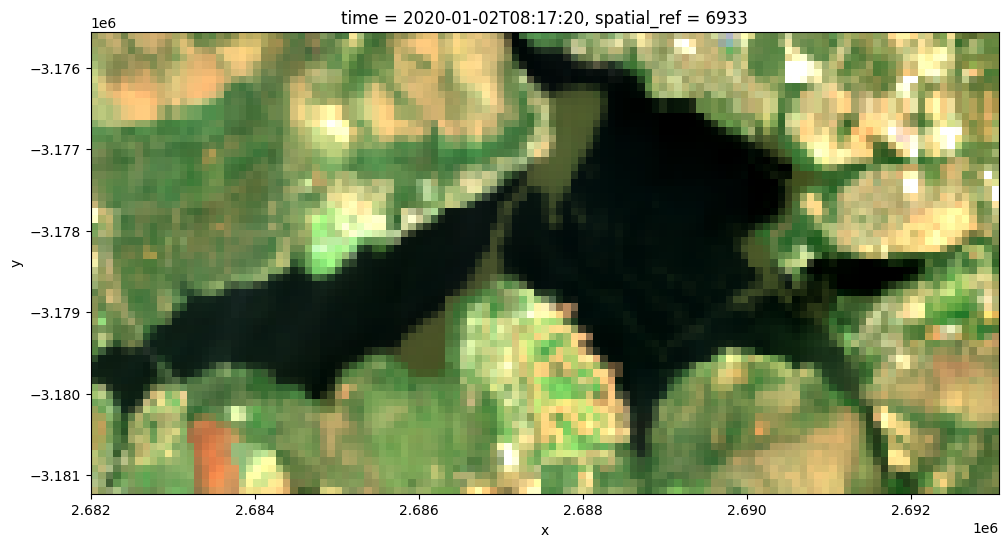

In [61]:
if verbose:
    ds0 = ds_msi.isel(time=0).copy() 
    rgb(ds0,bands=['msi04','msi03','msi02'])
    del ds0 ; gc.collect()